In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cftime
import matplotlib.patches as mpatches
# --- Configuration & Paths ---
# --- Define paths to datasets (from user update) ---
BASE_PATH_EMU = '/pscratch/sd/a/asubel/Chapter_2/Preds'
BASE_PATH_TRUTH = '/pscratch/sd/a/asubel/Data/Chapter_2'
EXPERIMENTS = {
    'Truth piControl': f'{BASE_PATH_TRUTH}/CESM2_piControl_Detrended.zarr',
    'Truth Holocene': f'{BASE_PATH_TRUTH}/Holocene_Processed_Detrended.zarr',
    'Emu: piC -> piC': f'{BASE_PATH_EMU}/CM4_Reconstruct_Baseline_CESM2_piControl.zarr',
    'Emu: piC -> Holo': f'{BASE_PATH_EMU}/CM4_Reconstruct_Baseline_CESM2_Holocene.zarr', 
    'Emu: Holo -> Holo': f'{BASE_PATH_EMU}/CM4_Reconstruct_Holocene_CESM2_Holocene.zarr',
    'Emu: Holo -> piC': f'{BASE_PATH_EMU}/CM4_Reconstruct_Holocene_CESM2_piControl.zarr',
}

VAR_NAME = 'thetao'
COLORS = {'Truth': 'black', 'Matched': '#1f77b4', 'Cross': '#d62728'}

# --- Utility Functions ---

def coarsen_fft(freqs, fft, coarsen_factor=1):
    """Smoothes the power spectrum."""
    true_freqs = 1/freqs
    weighted = fft * true_freqs
    new_size = int(len(fft[1:]) / coarsen_factor)
    c_fft = np.zeros(new_size)
    c_freqs = np.zeros(new_size)
    for i in range(new_size):
        s = slice(i*coarsen_factor, (i+1)*coarsen_factor)
        c_fft[i] = weighted[s].sum() / true_freqs[s].sum()
        c_freqs[i] = true_freqs[s].mean()
    return 1/c_freqs, c_fft

def compute_autocorrelation(ts, max_lag=48):
    vals = ts.values - ts.values.mean()
    corrs = [1.0]
    for lag in range(1, max_lag + 1):
        c = np.corrcoef(vals[:-lag], vals[lag:])[0, 1]
        corrs.append(c)
    return np.arange(max_lag + 1), np.array(corrs)

def compute_lagged_corr_chunked(ts1, ts2, max_lag=48, chunk_years=10):
    """Computes correlation between ts1 and lagged ts2 (ts1 leads ts2)."""
    # Align
    ts1, ts2 = xr.align(ts1, ts2, join='inner')
    vals1, vals2 = ts1.values, ts2.values
    
    months_per_chunk = chunk_years * 12
    n_chunks = len(vals1) // months_per_chunk
    if n_chunks < 1: return None, None, None

    lags = np.arange(max_lag + 1)
    all_corrs = []

    for i in range(n_chunks):
        s = i * months_per_chunk
        e = (i + 1) * months_per_chunk
        v1 = vals1[s:e]
        v2 = vals2[s:e]
        
        chunk_corrs = []
        for lag in lags:
            if lag == 0:
                c = np.corrcoef(v1, v2)[0, 1]
            else:
                # ts1 leads ts2 (positive lag)
                c = np.corrcoef(v1[lag:], v2[:-lag])[0, 1]
            chunk_corrs.append(c)
        all_corrs.append(chunk_corrs)
    
    arr = np.array(all_corrs)
    return lags, np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)

def weighted_mean(da, area):
    weights = area.sel(y=da.y, x=da.x)
    return (da * weights).sum(dim=['y', 'x']) / weights.sum(dim=['y', 'x'])

def compute_index(da, area, boxes):
    clim = da.groupby('time.month').mean('time')
    anom = da.groupby('time.month') - clim
    
    if isinstance(boxes, dict):
        comps = []
        for name, box in boxes.items():
            if name == 'Global':
                comp = weighted_mean(anom, area).compute()
            else:
                comp = weighted_mean(anom.sel(x=slice(*box[:2]), y=slice(*box[2:])), area).compute()
            comps.append(comp)
        return comps[0] - comps[1]
    else:
        return weighted_mean(anom.sel(x=slice(*boxes[:2]), y=slice(*boxes[2:])), area).compute()

# --- Data Loading & Alignment Logic ---

print("Defining Slices...")
# Explicitly loading time arrays to define slices as requested
picontrol_times = xr.open_zarr(f'{BASE_PATH_EMU}/CM4_Reconstruct_Baseline_CESM2_piControl.zarr')['time'].values
midHolo_times = xr.open_zarr(f'{BASE_PATH_EMU}/CM4_Reconstruct_Holocene_CESM2_Holocene.zarr')['time'].values

picontrol_slice = slice(picontrol_times[0], picontrol_times[-1])
midHolo_slice = slice(midHolo_times[0], midHolo_times[-1])

print(f"  piControl Slice: {picontrol_slice.start} to {picontrol_slice.stop}")
print(f"  midHolo Slice:   {midHolo_slice.start} to {midHolo_slice.stop}")

print("Loading datasets...")
datasets = {}

# Load Truth to get Area
ds_truth_ref = xr.open_zarr(EXPERIMENTS['Truth piControl'], consolidated=True)
if 'areacello' in ds_truth_ref:
    area = ds_truth_ref['areacello']
else:
    lat_vals = ds_truth_ref.lat if 'lat' in ds_truth_ref.coords else ds_truth_ref.y
    lon_vals = ds_truth_ref.lon if 'lon' in ds_truth_ref.coords else ds_truth_ref.x
    R = 6.371e6
    dy = R * np.deg2rad(np.mean(np.diff(lat_vals)))
    dx = R * np.cos(np.deg2rad(lat_vals)) * np.deg2rad(np.mean(np.diff(lon_vals)))
    area = (dy * dx).broadcast_like(ds_truth_ref[VAR_NAME].isel(time=0, lev=0))

# if 'latitude' in area.coords: area = area.rename({'latitude':'y', 'longitude':'x'})
# if 'lat' in area.coords: area = area.rename({'lat':'y', 'lon':'x'})

for name, path in EXPERIMENTS.items():
    print(f"  Loading {name}...")
    ds = xr.open_zarr(path, consolidated=True)
    if 'year' in ds.dims: ds = ds.rename({'year': 'time'})
    
    # --- Explicit Slicing Application ---
    # Determine which slice to use based on the experiment type
    if 'piControl' in name or 'piC -> piC' in name or 'Holo -> piC' in name:
        target_slice = picontrol_slice
    elif 'Holocene' in name or 'Holo -> Holo' in name or 'piC -> Holo' in name:
        target_slice = midHolo_slice
    else:
        print(f"    WARNING: Could not determine slice for {name}. Skipping slice.")
        target_slice = None
        
    if target_slice:
        try:
            ds = ds.sel(time=target_slice)
        except Exception as e:
            print(f"    WARNING: Time slicing failed for {name}: {e}")
    
    datasets[name] = ds

# 3. Compute All Indices Once
indices_db = {'Nino3.4': {}, 'DMI': {}, 'rATL3': {}, 'AMO': {}}
defs = {
    'AMO': {
        'NorthAtlantic': (280, 360, 0, 60), 
        'Global': (0, 360, -60, 60)
    },
    'Nino3.4': (190, 240, -5, 5),
    'DMI': {'West': (50, 70, -10, 10), 'East': (90, 110, -10, 0)},
    'rATL3': {'Atl3': (340, 360, -3, 3), 'Global': 'Global'}    
}

print("Computing Indices...")
for name, ds in datasets.items():
    sst = ds[VAR_NAME]
    if 'lev' in sst.coords: sst = sst.isel(lev=0)
    elif 'z_t' in sst.coords: sst = sst.isel(z_t=0)
    
    indices_db['AMO'][name] = compute_index(sst, area, defs['AMO'])
    indices_db['DMI'][name] = compute_index(sst, area, defs['DMI'])
    indices_db['Nino3.4'][name] = compute_index(sst, area, defs['Nino3.4'])
    indices_db['rATL3'][name] = compute_index(sst, area, defs['rATL3'])

print("Setup Complete. Variables 'indices_db' ready.")

Defining Slices...
  piControl Slice: 1100-02-14 00:00:00 to 1200-01-15 12:00:00
  midHolo Slice:   0595-02-14 00:00:00 to 0695-01-15 12:00:00
Loading datasets...
  Loading Truth piControl...
  Loading Truth Holocene...
  Loading Emu: piC -> piC...
  Loading Emu: piC -> Holo...
  Loading Emu: Holo -> Holo...
  Loading Emu: Holo -> piC...
Computing Indices...
Setup Complete. Variables 'indices_db' ready.


In [6]:
def process_amo_signal(amo_monthly_da):
    """
    Replicates NCL post-processing:
    1. Resample to Annual Mean
    2. Apply Decadal Smoothing (approximated here with 10yr rolling)
    """
    # 1. Annual Mean
    amo_annual = amo_monthly_da.resample(time='AS').mean()
    
    # 2. Decadal Smoothing
    # The NCL script uses specific Gaussian weights. 
    # A centered 10-year rolling mean is a standard Python equivalent.
    amo_smoothed = amo_annual.rolling(time=5, center=True, min_periods=5).mean()
    
    return amo_annual, amo_smoothed

# Example Usage:
# print("Post-processing AMO...")
# for name, da_amo in indices_db['AMO'].items():
#     ann, smooth = process_amo_signal(da_amo)
    
#     # You can now plot 'smooth' to match the NCL "AMO Signal" plot
#     plt.figure(figsize=(10, 4))
#     plt.plot(ann.time, ann.values, color='lightgray', label='Annual')
#     plt.plot(smooth.time, smooth.values, color='black', linewidth=2, label='Smoothed')
#     plt.title(f"AMO Index - {name}")
#     plt.legend()
#     plt.show()

In [6]:
def compute_autocorrelation_chunked(ts, max_lag=20, chunk_size=50):
    """
    Computes autocorrelation with uncertainty bounds (std dev across chunks).
    
    Parameters:
    -----------
    ts : xarray.DataArray
        Time series data (1D).
    max_lag : int
        Maximum lag to compute.
    chunk_size : int
        Size of chunks to estimate uncertainty (in same units as time dimension).
        
    Returns:
    --------
    lags : np.array
        Lag indices.
    mean_corr : np.array
        Mean autocorrelation across chunks.
    std_corr : np.array
        Standard deviation of autocorrelation across chunks.
    """
    # Drop NaNs to ensure clean chunks
    vals = ts.dropna(dim=ts.dims[0]).values
    
    # Detrend/Demean global or per chunk? Usually per chunk for robust AC.
    # Here we demean globally to match standard AC definition if stationary.
    vals = vals - np.mean(vals)
    
    n_samples = len(vals)
    n_chunks = n_samples // chunk_size
    
    lags = np.arange(max_lag + 1)
    
    # If time series is too short for multiple chunks, return single estimate with 0 std
    if n_chunks < 2:
        corrs = [1.0]
        for lag in range(1, max_lag + 1):
            if lag < len(vals):
                c = np.corrcoef(vals[:-lag], vals[lag:])[0, 1]
            else:
                c = np.nan
            corrs.append(c)
        return lags, np.array(corrs), np.zeros_like(corrs)

    # Compute AC for each chunk
    all_chunk_corrs = []
    
    for i in range(n_chunks):
        s_idx = i * chunk_size
        e_idx = s_idx + chunk_size
        chunk = vals[s_idx:e_idx]
        
        # Demean chunk for local AC calculation
        chunk = chunk - np.mean(chunk)
        
        chunk_corrs = [1.0]
        for lag in range(1, max_lag + 1):
            c = np.corrcoef(chunk[:-lag], chunk[lag:])[0, 1]
            chunk_corrs.append(c)
        all_chunk_corrs.append(chunk_corrs)
    
    # Statistics
    all_chunk_corrs = np.array(all_chunk_corrs)
    mean_corr = np.nanmean(all_chunk_corrs, axis=0)
    std_corr = np.nanstd(all_chunk_corrs, axis=0)
    
    return lags, mean_corr, std_corr

# ==============================================================================
# 2. HELPER: SPECTRUM COARSENING
# ==============================================================================
def coarsen_fft(freqs, fft, coarsen_factor=2):
    """Smoothes the power spectrum for display."""
    if len(freqs) < coarsen_factor * 5:
        return freqs, fft # Return raw if too short
        
    true_freqs = 1/freqs
    weighted = fft * true_freqs
    
    # Handle edge case where size isn't perfectly divisible
    limit = (len(fft) // coarsen_factor) * coarsen_factor
    weighted = weighted[1:limit] # Skip 0 freq
    true_freqs = true_freqs[1:limit]
    
    new_size = len(weighted) // coarsen_factor
    
    c_fft = np.zeros(new_size)
    c_freqs = np.zeros(new_size)
    
    for i in range(new_size):
        s = slice(i*coarsen_factor, (i+1)*coarsen_factor)
        c_fft[i] = weighted[s].sum() / true_freqs[s].sum()
        c_freqs[i] = true_freqs[s].mean()
        
    return 1/c_freqs, c_fft

# ==============================================================================
# 3. MAIN PLOTTING FUNCTION
# ==============================================================================
def plot_amo_analysis(amo_annual_db, amo_smoothed_db, colors):
    """
    Generates the 2x3 plots for Annual and Smoothed AMO analysis.
    """
    
    # Configuration for the two figures
    configs = [
        {
            'title': 'Annual Mean',
            'db': amo_annual_db,
            'dt': 1.0,
            'slice_yrs': 300,
            'max_lag': 20,
            'chunk_size': 50
        },
        {
            'title': 'Smoothed (Decadal)',
            'db': amo_smoothed_db,
            'dt': 1.0,
            'slice_yrs': 300,
            'max_lag': 20,
            'chunk_size': 50
        }
    ]
    
    rows_layout = [
        {'title': 'piControl Background', 'truth': 'Truth piControl', 
         'matched': 'Emu: piC -> piC', 'cross': 'Emu: Holo -> piC', 'idx': 0},
        {'title': 'Holocene Background', 'truth': 'Truth Holocene', 
         'matched': 'Emu: Holo -> Holo', 'cross': 'Emu: piC -> Holo', 'idx': 1}
    ]

    for cfg in configs:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
        fig.suptitle(f"AMO Analysis: {cfg['title']}", fontsize=20, weight='bold')

        for r in rows_layout:
            ax_ts, ax_spec, ax_auto = axes[r['idx']]
            
            # Row Label
            ax_ts.annotate(r['title'], xy=(-0.25, 0.5), xycoords='axes fraction', 
                           fontsize=16, weight='bold', rotation=90, va='center')

            # Experiments to plot in this row
            exps = [
                (r['truth'], colors['Truth']),
                (r['matched'], colors['Matched']),
                (r['cross'], colors['Cross'])
            ]

            for key, color in exps:
                if key not in cfg['db']: continue
                
                # Get Data
                ts = cfg['db'][key]
                ts_valid = ts.dropna(dim=ts.dims[0]) # Remove NaNs for calcs
                
                if len(ts_valid) < 10: continue

                # --- 1. Time Series ---
                # Plot end of record
                ts_plot = ts.isel({ts.dims[0]: slice(-cfg['slice_yrs'], None)})
                # Create dummy time axis if needed or use existing
                if 'time' in ts_plot.dims:
                    x_axis = ts_plot.time
                elif 'year' in ts_plot.dims:
                    x_axis = ts_plot.year
                else:
                    x_axis = np.arange(len(ts_plot))
                    
                ax_ts.plot(x_axis, ts_plot, color=color, alpha=0.8, lw=1.5, 
                           label=key if r['idx'] == 0 else None)

                # --- 2. Power Spectrum ---
                vals = ts_valid.values
                freqs = np.fft.rfftfreq(len(vals), d=cfg['dt'])
                psd = np.abs(np.fft.rfft(vals))**2
                f_coarse, p_coarse = coarsen_fft(1/freqs, psd, coarsen_factor=3)
                ax_spec.loglog(f_coarse, p_coarse, color=color, lw=1.5)

                # --- 3. Autocorrelation with Uncertainty ---
                lags, mean_corr, std_corr = compute_autocorrelation_chunked(
                    ts_valid, max_lag=cfg['max_lag'], chunk_size=cfg['chunk_size']
                )
                
                ax_auto.plot(lags, mean_corr, color=color, lw=1.5)
                ax_auto.fill_between(lags, mean_corr - std_corr, mean_corr + std_corr,
                                     color=color, alpha=0.2, edgecolor='none')

            # Formatting
            ax_ts.set_title(f"Time Series (Last {cfg['slice_yrs']} Yrs)")
            ax_ts.set_ylabel('Anomaly (°C)')
            ax_ts.set_xlabel('Time')
            
            ax_spec.set_title('Power Spectrum')
            ax_spec.set_xlabel('Period (Years)')
            ax_spec.invert_xaxis()
            ax_spec.set_xlim(100, 2)
            
            ax_auto.set_title('Autocorrelation')
            ax_auto.set_xlabel('Lag (Years)')
            ax_auto.axhline(0, c='k', ls=':', lw=0.8)
            ax_auto.set_ylim(-0.5, 1.0)

        # Common Legend
        fig.legend(loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=10)
        plt.show()

Post-processing AMO (Annual & Smoothed)...


<string>:7: FutureWarning: 'AS' is deprecated and will be removed in a future version. Please use 'YS' instead of 'AS'.
<string>:7: FutureWarning: 'AS' is deprecated and will be removed in a future version. Please use 'YS' instead of 'AS'.
<string>:7: FutureWarning: 'AS' is deprecated and will be removed in a future version. Please use 'YS' instead of 'AS'.
<string>:7: FutureWarning: 'AS' is deprecated and will be removed in a future version. Please use 'YS' instead of 'AS'.
<string>:7: FutureWarning: 'AS' is deprecated and will be removed in a future version. Please use 'YS' instead of 'AS'.
<string>:7: FutureWarning: 'AS' is deprecated and will be removed in a future version. Please use 'YS' instead of 'AS'.
/tmp/ipykernel_1576366/4191351890.py:83: RuntimeWarning: divide by zero encountered in divide
  f, p = (1/freqs, psd)
/tmp/ipykernel_1576366/4191351890.py:83: RuntimeWarning: divide by zero encountered in divide
  f, p = (1/freqs, psd)
/tmp/ipykernel_1576366/4191351890.py:83: Run

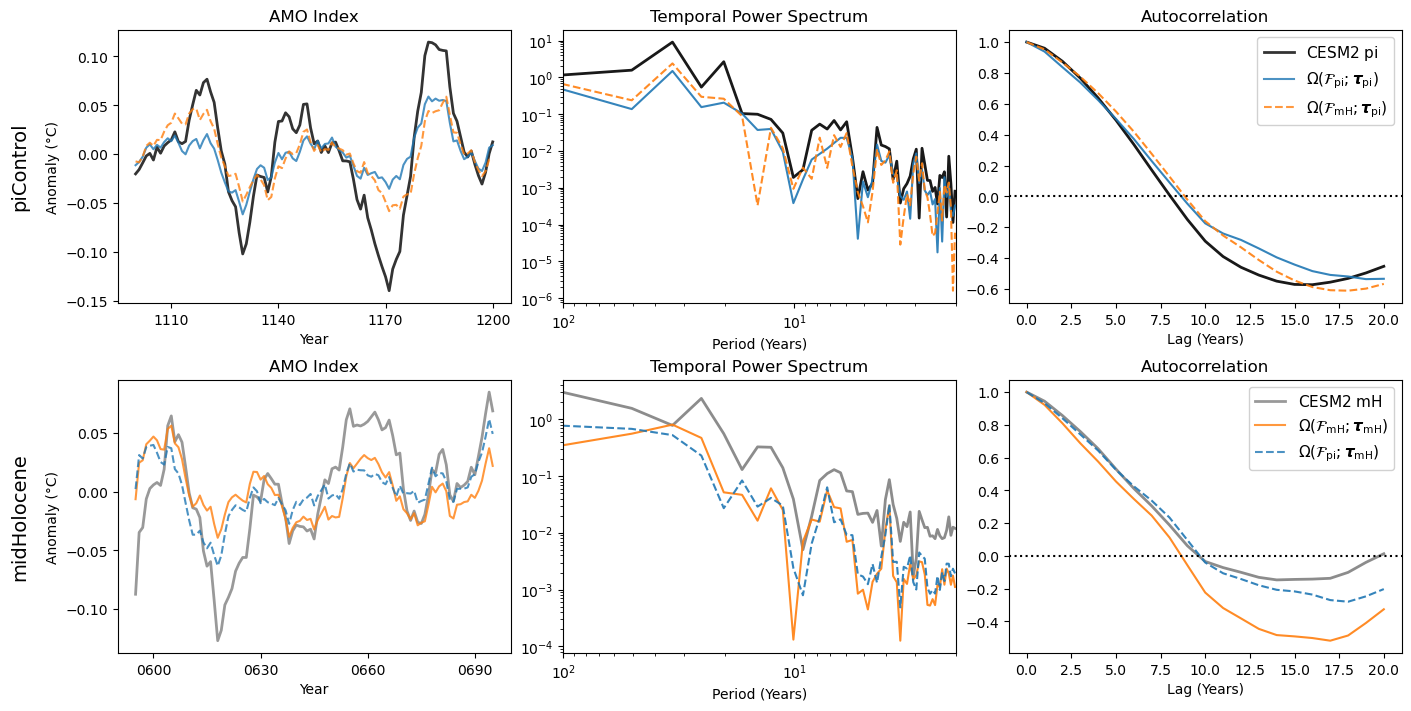

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# CELL 2: AMO POST-PROCESSING & PLOTTING
# ==============================================================================

# 1. Plotting Styling Configurations
# ----------------------------------
styles = {
    'Truth piControl':   {'c': 'k',       'ls': '-',  'lw': 2,   'label': r'CESM2 $\mathrm{pi}$'},
    'Emu: piC -> piC':   {'c': 'C0',      'ls': '-',  'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{pi}}; \boldsymbol{\tau}_{\mathrm{pi}})$'},
    'Emu: Holo -> piC':  {'c': 'C1',      'ls': '--', 'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{mH}}; \boldsymbol{\tau}_{\mathrm{pi}})$'},
    
    'Truth Holocene':    {'c': 'gray',    'ls': '-',  'lw': 2,   'label': r'CESM2 $\mathrm{mH}$'},
    'Emu: Holo -> Holo': {'c': 'C1',      'ls': '-',  'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{mH}}; \boldsymbol{\tau}_{\mathrm{mH}})$'},
    'Emu: piC -> Holo':  {'c': 'C0',      'ls': '--', 'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{pi}}; \boldsymbol{\tau}_{\mathrm{mH}})$'},
}

config = {
    'title_suffix': 'Smoothed (Decadal)',
    'sampling_dt': 1.0,       # 1 sample per year
    'time_slice': 200,        # Plot 100 years
    'lag_units': 'Years',
    'fft_label': 'Cycles/Year'
}

rows = [
    {'title': 'piControl', 'truth': 'Truth piControl', 
     'matched': 'Emu: piC -> piC', 'cross': 'Emu: Holo -> piC', 'row': 0},
    {'title': 'midHolocene', 'truth': 'Truth Holocene', 
     'matched': 'Emu: Holo -> Holo', 'cross': 'Emu: piC -> Holo', 'row': 1}
]

# 2. Processing Loop
# ------------------
amo_annual_db = {}
amo_smoothed_db = {}

print("Post-processing AMO (Annual & Smoothed)...")
for name, da_amo in indices_db['AMO'].items():
    ann, smooth = process_amo_signal(da_amo)
    amo_annual_db[name] = ann
    amo_smoothed_db[name] = smooth

config['data_db'] = amo_smoothed_db

# 3. Generate Plot (Smoothed Only)
# --------------------------------
# Shrunk figsize to (14, 7) to make labels relatively larger
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

# Removed bold weight, adjusted font size
for r in rows:
    ax_ts, ax_spec, ax_auto = axes[r['row']]
    
    # Row Title: removed bold weight, adjusted font size, added ha='center'
    ax_ts.annotate(r['title'], xy=(-0.25, 0.5), xycoords='axes fraction', 
                   fontsize=14, rotation=90, va='center', ha='center')
    
    keys = [r['truth'], r['matched'], r['cross']]
    
    for key in keys:
        if key not in config['data_db']: continue
        
        sty = styles[key]
        
        # Get data and handle NaNs (crucial for smoothed FFTs)
        ts = config['data_db'][key]
        ts_valid = ts.dropna('time') 
        
        # 1. Time Series Plot
        to_plot = ts.isel(time=slice(-config['time_slice'], None))
        to_plot.plot(ax=ax_ts, color=sty['c'], ls=sty['ls'], lw=sty['lw'], 
                     alpha=0.8, label=sty['label'])
        
        # 2. Power Spectrum
        if len(ts_valid) > 10:
            vals = ts_valid.values
            freqs = np.fft.rfftfreq(len(vals), d=config['sampling_dt'])
            psd = np.abs(np.fft.rfft(vals))**2
            
            f, p = (1/freqs, psd)
            ax_spec.loglog(f, p, color=sty['c'], ls=sty['ls'], lw=sty['lw'], alpha=0.9)
        
        # 3. Autocorrelation
        if len(ts_valid) > 10:
            l, c = compute_autocorrelation(ts_valid, max_lag=20) # 40 year lag
            ax_auto.plot(l, c, color=sty['c'], ls=sty['ls'], lw=sty['lw'], alpha=0.9)

    # Subplot Formatting
    ax_ts.set_title(f"AMO Index")
    ax_ts.set_ylabel('Anomaly (°C)')
    ax_ts.set_xlabel('Year')
    
    ax_spec.set_title('Temporal Power Spectrum')
    ax_spec.set_xlabel(f"Period ({config['lag_units']})")
    ax_spec.invert_xaxis()
    ax_spec.set_xlim(100, 2) 
    
    ax_auto.set_title('Autocorrelation')
    ax_auto.set_xlabel(f"Lag ({config['lag_units']})")
    ax_auto.axhline(0, c='k', ls=':')

# Create separate legends for the piControl (Row 0) and Holocene (Row 1) panels
for row_idx in range(2):
    # Extract handles and labels from the time series subplot of the current row
    handles, labels = axes[row_idx, 0].get_legend_handles_labels()
    
    # Place the legend in the upper right of the Autocorrelation plot for that specific row
    axes[row_idx, 2].legend(handles, labels, loc='upper right', fontsize=11, framealpha=0.9)

plt.savefig('./Figures_For_Paper_Final/AMO_Smoothed_Supp.png', dpi=300)
plt.show()

Generating Nino3.4 and DMI Power Spectra & Extracting Metrics...

NINO3.4 METRICS (Band: 2.0-7.0 Years)

--- piControl Background ---


/tmp/ipykernel_976646/2773685274.py:91: RuntimeWarning: divide by zero encountered in divide
  f_coarse_months, p_coarse = coarsen_fft(1/freqs, psd, coarsen_factor=2)


AttributeError: module 'scipy.integrate' has no attribute 'trapz'

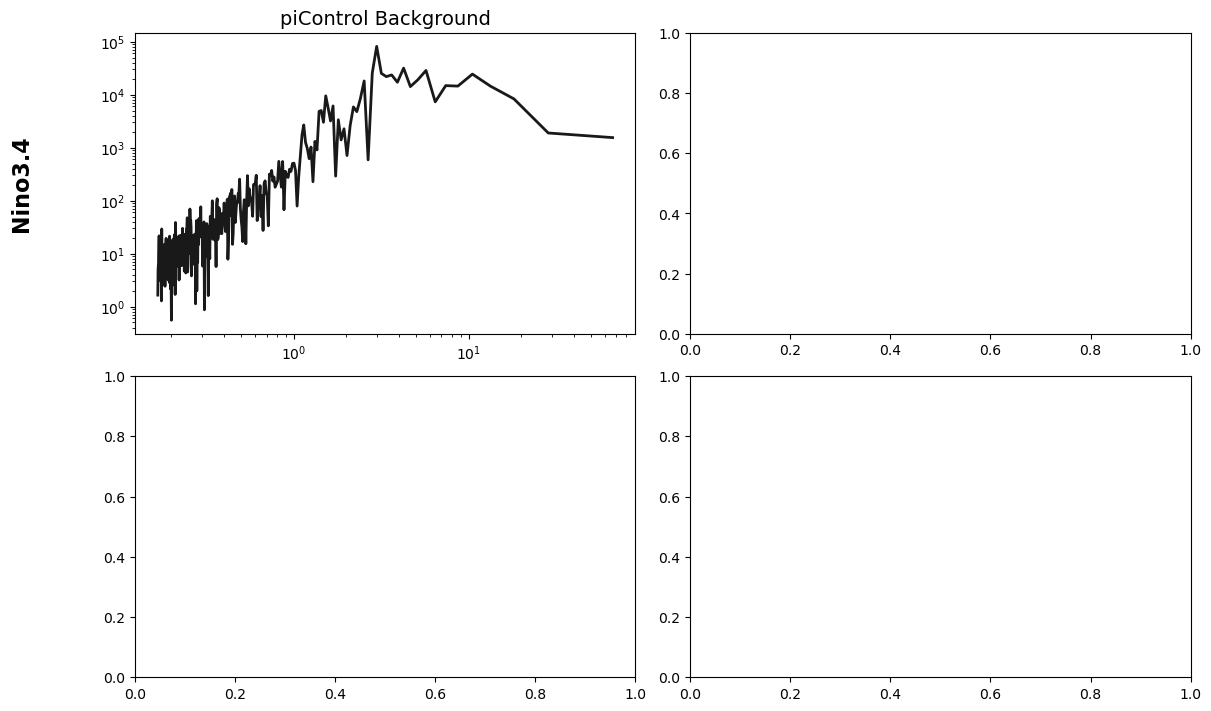

In [16]:
# ==============================================================================
# CELL 3: NINO3.4 AND DMI POWER SPECTRA (2x2 PLOT)
# ==============================================================================
styles = {
    'Truth piControl':   {'c': 'k',       'ls': '-',  'lw': 2, 'label': r'CESM2 $\mathrm{pi}$'},
    'Emu: piC -> piC':   {'c': 'C0',      'ls': '-',  'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{pi}}; \boldsymbol{\tau}_{\mathrm{pi}})$'},
    'Emu: Holo -> piC':  {'c': 'C1',      'ls': '--', 'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{mH}}; \boldsymbol{\tau}_{\mathrm{pi}})$'},
    
    'Truth Holocene':    {'c': 'gray',    'ls': '-',  'lw': 2, 'label': r'CESM2 $\mathrm{mH}$'},
    'Emu: Holo -> Holo': {'c': 'C1',      'ls': '-',  'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{mH}}; \boldsymbol{\tau}_{\mathrm{mH}})$'},
    'Emu: piC -> Holo':  {'c': 'C0',      'ls': '--', 'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{pi}}; \boldsymbol{\tau}_{\mathrm{mH}})$'},
}


print("Generating Nino3.4 and DMI Power Spectra (2x2)...")

fig_spectra, axes_spec = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

indices_to_plot = [
    {'name': 'Nino3.4', 'row': 0, 'units': 'Months'},
    {'name': 'DMI', 'row': 1, 'units': 'Months'}
]

cols = [
    {'title': 'piControl Background', 'truth': 'Truth piControl', 
     'matched': 'Emu: piC -> piC', 'cross': 'Emu: Holo -> piC', 'col': 0},
    {'title': 'midHolocene Background', 'truth': 'Truth Holocene', 
     'matched': 'Emu: Holo -> Holo', 'cross': 'Emu: piC -> Holo', 'col': 1}
]

for idx_cfg in indices_to_plot:
    index_name = idx_cfg['name']
    row = idx_cfg['row']
    
    # Set Row Title
    axes_spec[row, 0].annotate(index_name, xy=(-0.25, 0.5), xycoords='axes fraction', 
                               fontsize=16, weight='bold', rotation=90, va='center')
    
    for c in cols:
        ax = axes_spec[row, c['col']]
        ax.set_title(c['title'], fontsize=14)
        
        keys = [c['truth'], c['matched'], c['cross']]
        for key in keys:
            if key not in indices_db[index_name]: continue
            
            sty = styles[key]
            ts = indices_db[index_name][key]
            ts_valid = ts.dropna('time')
            
            if len(ts_valid) > 10:
                vals = ts_valid.values
                # Assuming monthly data for Nino/DMI, so dt=1 month
                freqs = np.fft.rfftfreq(len(vals), d=1.0)
                psd = np.abs(np.fft.rfft(vals))**2
                
                # f_coarse returned here is Period in Months
                f_coarse_months, p_coarse = coarsen_fft(1/freqs, psd, coarsen_factor=2)
                
                # Convert Period (Months) to Period (Years)
                period_years = f_coarse_months / 12.0
                
                ax.loglog(period_years, p_coarse, color=sty['c'], ls=sty['ls'], lw=sty['lw'], 
                          alpha=0.9, label=sty['label'])

        ax.set_xlabel('Period (Years)', fontsize=12)
        ax.set_ylabel('Power', fontsize=12)
        
        # 10 years down to 0.5 years (6 months). 
        # Setting the larger number first naturally inverts the log-axis.
        ax.set_xlim(15, 0.25) 
        ax.grid(True, which="both", ls=":", alpha=0.5)

# Add legends only to the top row
for col in range(2):
    handles, labels = axes_spec[0, col].get_legend_handles_labels()
    axes_spec[0, col].legend(handles, labels, loc='lower left', fontsize=10)

plt.savefig('./Figures_For_Paper_Final/Power_Spectra_Nino_DMI.png', dpi=300)
plt.show()


# ==============================================================================
# CELL 4: rATL3 POST-PROCESSING & PLOTTING (Like AMO)
# ==============================================================================

print("Generating rATL3 Analysis (2x3)...")

fig_ratl, axes_ratl = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

rows_ratl = [
    {'title': 'piControl', 'truth': 'Truth piControl', 
     'matched': 'Emu: piC -> piC', 'cross': 'Emu: Holo -> piC', 'row': 0},
    {'title': 'midHolocene', 'truth': 'Truth Holocene', 
     'matched': 'Emu: Holo -> Holo', 'cross': 'Emu: piC -> Holo', 'row': 1}
]

# rATL3 is usually monthly, but if we want to match AMO style we can plot it as is.
for r in rows_ratl:
    ax_ts, ax_spec, ax_auto = axes_ratl[r['row']]
    
    ax_ts.annotate(r['title'], xy=(-0.25, 0.5), xycoords='axes fraction', 
                   fontsize=14, rotation=90, va='center', ha='center')
    
    keys = [r['truth'], r['matched'], r['cross']]
    
    for key in keys:
        if key not in indices_db['rATL3']: continue
        
        sty = styles[key]
        ts = indices_db['rATL3'][key]
        ts_valid = ts.dropna('time') 
        
        # 1. Time Series Plot (Last 300 months = 25 years)
        to_plot = ts.isel(time=slice(-300, None))
        # Use simple numeric index for x-axis if time formatting is tricky
        x_axis = np.arange(len(to_plot))
        ax_ts.plot(x_axis, to_plot.values, color=sty['c'], ls=sty['ls'], lw=sty['lw'], 
                   alpha=0.8, label=sty['label'])
        
        # 2. Power Spectrum
        if len(ts_valid) > 10:
            vals = ts_valid.values
            freqs = np.fft.rfftfreq(len(vals), d=1.0) # dt=1 month
            psd = np.abs(np.fft.rfft(vals))**2
            
            f, p = (1/freqs, psd)
            f_coarse_months, p_coarse = coarsen_fft(f, p, coarsen_factor=2)
            
            # Convert Period (Months) to Period (Years)
            period_years = f_coarse_months / 12.0
            
            ax_spec.loglog(period_years, p_coarse, color=sty['c'], ls=sty['ls'], lw=sty['lw'], alpha=0.9)
        
        # 3. Autocorrelation
        if len(ts_valid) > 10:
            # For monthly data, max lag of 48 months (4 years) is usually good
            l, c, _ = compute_autocorrelation_chunked(ts_valid, max_lag=48, chunk_size=120) 
            ax_auto.plot(l, c, color=sty['c'], ls=sty['ls'], lw=sty['lw'], alpha=0.9)

    # Subplot Formatting
    ax_ts.set_title("rATL3 Index")
    ax_ts.set_ylabel('Anomaly (°C)')
    ax_ts.set_xlabel('Months (Relative)')
    
    ax_spec.set_title('Power Spectrum')
    ax_spec.set_xlabel('Period (Years)')
    # 10 years down to 0.5 years
    ax_spec.set_xlim(15, 0.25) 
    
    ax_auto.set_title('Autocorrelation')
    ax_auto.set_xlabel("Lag (Months)")
    ax_auto.axhline(0, c='k', ls=':')

# Create legends
for row_idx in range(2):
    handles, labels = axes_ratl[row_idx, 0].get_legend_handles_labels()
    axes_ratl[row_idx, 2].legend(handles, labels, loc='upper right', fontsize=11, framealpha=0.9)

plt.savefig('./Figures_For_Paper_Final/rATL3_Supp.png', dpi=300)
plt.show()

Generating Nino3.4 and DMI Power Spectra & Extracting Metrics...

NINO3.4 METRICS (Band: 2.0-7.0 Years)

--- piControl Background ---
Truth piControl      | Var: 6663.09 | Peak: 2.90 yrs | Spread: 0.0786
Emu: piC -> piC      | Var: 6079.23 | Peak: 2.90 yrs | Spread: 0.0779
Emu: Holo -> piC     | Var: 5778.24 | Peak: 2.90 yrs | Spread: 0.0782

--- midHolocene Background ---
Truth Holocene       | Var: 5938.75 | Peak: 3.77 yrs | Spread: 0.0880
Emu: Holo -> Holo    | Var: 5540.60 | Peak: 3.77 yrs | Spread: 0.0875
Emu: piC -> Holo     | Var: 5608.78 | Peak: 3.77 yrs | Spread: 0.0876

DMI METRICS (Band: 1.0-10.0 Years)

--- piControl Background ---
Truth piControl      | Var: 1877.46 | Peak: 3.51 yrs | Spread: 0.2449
Emu: piC -> piC      | Var: 1569.92 | Peak: 3.51 yrs | Spread: 0.2463
Emu: Holo -> piC     | Var: 884.10 | Peak: 3.51 yrs | Spread: 0.2365

--- midHolocene Background ---
Truth Holocene       | Var: 1456.79 | Peak: 3.77 yrs | Spread: 0.2531
Emu: Holo -> Holo    | Var: 1228.14 |

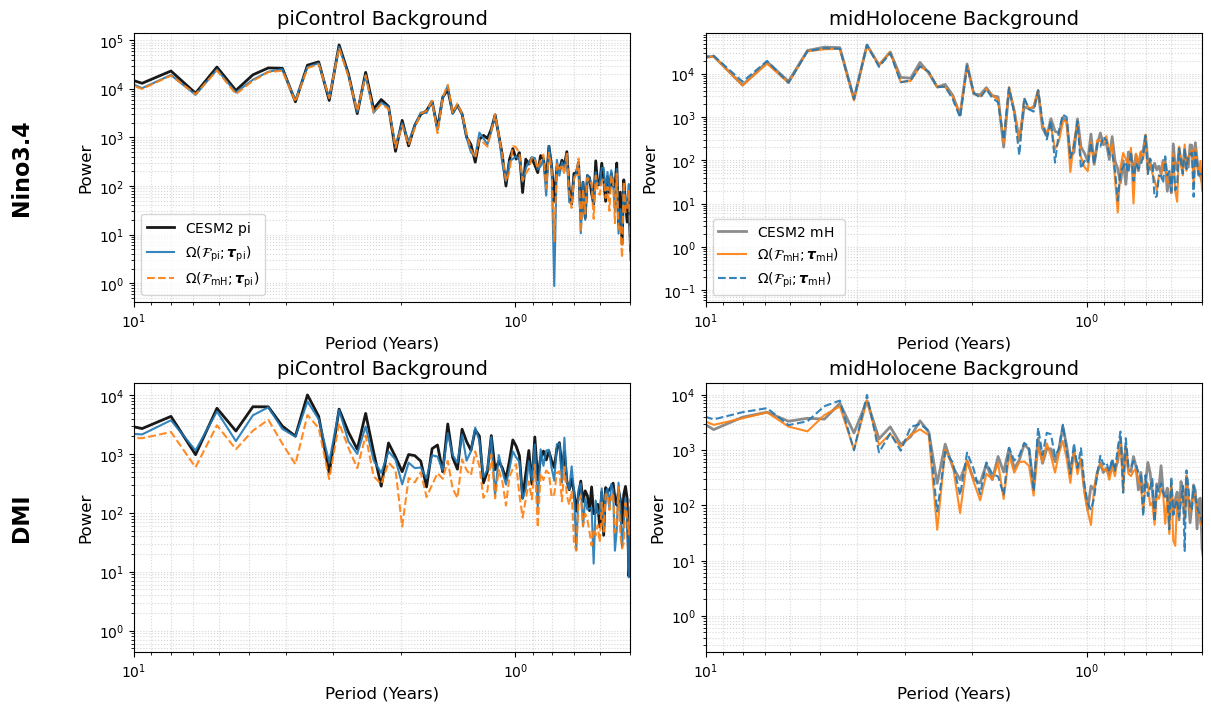

In [18]:
# ==============================================================================
# CELL 3: NINO3.4 AND DMI POWER SPECTRA WITH QUANTITATIVE METRICS
# ==============================================================================
import scipy.integrate as integrate

styles = {
    'Truth piControl':   {'c': 'k',       'ls': '-',  'lw': 2, 'label': r'CESM2 $\mathrm{pi}$'},
    'Emu: piC -> piC':   {'c': 'C0',      'ls': '-',  'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{pi}}; \boldsymbol{\tau}_{\mathrm{pi}})$'},
    'Emu: Holo -> piC':  {'c': 'C1',      'ls': '--', 'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{mH}}; \boldsymbol{\tau}_{\mathrm{pi}})$'},
    
    'Truth Holocene':    {'c': 'gray',    'ls': '-',  'lw': 2, 'label': r'CESM2 $\mathrm{mH}$'},
    'Emu: Holo -> Holo': {'c': 'C1',      'ls': '-',  'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{mH}}; \boldsymbol{\tau}_{\mathrm{mH}})$'},
    'Emu: piC -> Holo':  {'c': 'C0',      'ls': '--', 'lw': 1.5, 'label': r'$\Omega(\mathcal{F}_{\mathrm{pi}}; \boldsymbol{\tau}_{\mathrm{mH}})$'},
}

def calculate_spectral_metrics(freq_yr, power, band_years):
    """Calculates Total Variance, Peak Period, and Spectral Spread for a given band."""
    f_min, f_max = 1.0 / band_years[1], 1.0 / band_years[0]
    
    # Isolate the frequency band
    mask = (freq_yr >= f_min) & (freq_yr <= f_max)
    f_band = freq_yr[mask]
    p_band = power[mask]
    
    if len(f_band) < 2:
        return np.nan, np.nan, np.nan
        
    # 1. Total Variance in Band (Integration)
    # Sort by frequency to ensure proper trapezoidal integration
    sort_idx = np.argsort(f_band)
    f_band_sorted = f_band[sort_idx]
    p_band_sorted = p_band[sort_idx]
    
    # FIX: Use 'trapezoid' instead of the deprecated 'trapz'
    total_variance = integrate.trapezoid(p_band_sorted, x=f_band_sorted)
    
    # 2. Peak Period
    peak_idx = np.argmax(p_band)
    peak_period = 1.0 / f_band[peak_idx]
    
    # 3. Spectral Spread (Power-weighted standard deviation of frequency)
    # This quantifies how "broad" the peak is
    centroid_freq = np.sum(f_band * p_band) / np.sum(p_band)
    spread_freq = np.sqrt(np.sum(p_band * (f_band - centroid_freq)**2) / np.sum(p_band))
    
    return total_variance, peak_period, spread_freq

print("Generating Nino3.4 and DMI Power Spectra & Extracting Metrics...")

fig_spectra, axes_spec = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

# Define indices and the canonical bands to analyze
indices_to_plot = [
    {'name': 'Nino3.4', 'row': 0, 'band': (2.0, 7.0)}, # Typical ENSO band
    {'name': 'DMI',     'row': 1, 'band': (1.0, 10.0)} # Broad IOD band
]

cols = [
    {'title': 'piControl Background', 'truth': 'Truth piControl', 
     'matched': 'Emu: piC -> piC', 'cross': 'Emu: Holo -> piC', 'col': 0},
    {'title': 'midHolocene Background', 'truth': 'Truth Holocene', 
     'matched': 'Emu: Holo -> Holo', 'cross': 'Emu: piC -> Holo', 'col': 1}
]

for idx_cfg in indices_to_plot:
    index_name = idx_cfg['name']
    row = idx_cfg['row']
    eval_band = idx_cfg['band']
    
    # Set Row Title
    axes_spec[row, 0].annotate(index_name, xy=(-0.25, 0.5), xycoords='axes fraction', 
                               fontsize=16, weight='bold', rotation=90, va='center')
    print(f"\n{'='*50}\n{index_name.upper()} METRICS (Band: {eval_band[0]}-{eval_band[1]} Years)\n{'='*50}")
    
    for c in cols:
        ax = axes_spec[row, c['col']]
        ax.set_title(c['title'], fontsize=14)
        print(f"\n--- {c['title']} ---")
        
        keys = [c['truth'], c['matched'], c['cross']]
        for key in keys:
            if key not in indices_db[index_name]: continue
            
            sty = styles[key]
            ts = indices_db[index_name][key]
            ts_valid = ts.dropna('time')
            
            if len(ts_valid) > 10:
                vals = ts_valid.values
                freqs = np.fft.rfftfreq(len(vals), d=1.0) # dt=1 month
                psd = np.abs(np.fft.rfft(vals))**2
                
                # FIX: Drop the 0.0 frequency (DC component) to prevent divide-by-zero
                freqs = freqs[1:]
                psd = psd[1:]
                
                f_coarse_months, p_coarse = coarsen_fft(1/freqs, psd, coarsen_factor=2)
                
                # Frequencies and Periods
                period_years = f_coarse_months / 12.0
                f_coarse_freq_yr = 1.0 / period_years
                
                # Plotting
                ax.loglog(period_years, p_coarse, color=sty['c'], ls=sty['ls'], lw=sty['lw'], 
                          alpha=0.9, label=sty['label'])
                          
                # Calculate Metrics
                tot_var, peak_per, spread = calculate_spectral_metrics(f_coarse_freq_yr, p_coarse, eval_band)
                
                print(f"{key:<20} | Var: {tot_var:>6.2f} | Peak: {peak_per:>4.2f} yrs | Spread: {spread:>5.4f}")

        ax.set_xlabel('Period (Years)', fontsize=12)
        ax.set_ylabel('Power', fontsize=12)
        ax.set_xlim(10, 0.5) 
        ax.grid(True, which="both", ls=":", alpha=0.5)

# Add legends only to the top row
for col in range(2):
    handles, labels = axes_spec[0, col].get_legend_handles_labels()
    axes_spec[0, col].legend(handles, labels, loc='lower left', fontsize=10)

plt.savefig('./Figures_For_Paper_Final/Power_Spectra_Nino_DMI.png', dpi=300)
plt.show()

In [6]:
import numpy as np
from sklearn.metrics import r2_score, root_mean_squared_error
from scipy.stats import pearsonr

# Define the exact pairs of (Emulator Key, Truth Key) based on indices_db
comparisons = [
    ('Emu: piC -> piC', 'Truth piControl'),
    ('Emu: piC -> Holo', 'Truth Holocene'),
    ('Emu: Holo -> Holo', 'Truth Holocene'),
    ('Emu: Holo -> piC', 'Truth piControl')
]

# Loop through each climate mode directly from your dictionary
for mode, datasets in indices_db.items():
    print(f"{'='*50}")
    print(f"Metrics for {mode}")
    print(f"{'='*50}")
    
    for emu_key, truth_key in comparisons:
        try:
            # Extract the raw 1D numpy arrays from the xarray.DataArrays
            true_ts = datasets[truth_key].values
            pred_ts = datasets[emu_key].values
        except KeyError as e:
            print(f"  [Error] Key {e} missing for {mode}. Skipping.")
            continue
            
        # Mask out NaNs to ensure scipy and sklearn don't throw errors
        valid_mask = ~np.isnan(true_ts) & ~np.isnan(pred_ts)
        true_clean = true_ts[valid_mask]
        pred_clean = pred_ts[valid_mask]
        
        # Guard clause if arrays are empty after masking
        if len(true_clean) < 2:
            print(f"  [Warning] Insufficient valid data for {emu_key}. Skipping.")
            continue
            
        # Compute the metrics
        r_squared = r2_score(true_clean, pred_clean)
        correlation, p_value = pearsonr(true_clean, pred_clean)
        rmse = root_mean_squared_error(true_clean, pred_clean)
        
        # Print the formatted results
        print(f"Model: {emu_key}  (vs. {truth_key})")
        print(f"  R^2:   {r_squared:.4f}")
        print(f"  Corr:  {correlation:.4f} (p-val: {p_value:.4e})")
        print(f"  RMSE:  {rmse:.4f}\n")

print("Metric evaluation complete.")

Metrics for Nino3.4
Model: Emu: piC -> piC  (vs. Truth piControl)
  R^2:   0.9779
  Corr:  0.9893 (p-val: 0.0000e+00)
  RMSE:  0.1731

Model: Emu: piC -> Holo  (vs. Truth Holocene)
  R^2:   0.9732
  Corr:  0.9866 (p-val: 0.0000e+00)
  RMSE:  0.1802

Model: Emu: Holo -> Holo  (vs. Truth Holocene)
  R^2:   0.9802
  Corr:  0.9903 (p-val: 0.0000e+00)
  RMSE:  0.1550

Model: Emu: Holo -> piC  (vs. Truth piControl)
  R^2:   0.9739
  Corr:  0.9881 (p-val: 0.0000e+00)
  RMSE:  0.1880

Metrics for DMI
Model: Emu: piC -> piC  (vs. Truth piControl)
  R^2:   0.8778
  Corr:  0.9371 (p-val: 0.0000e+00)
  RMSE:  0.2205

Model: Emu: piC -> Holo  (vs. Truth Holocene)
  R^2:   0.8124
  Corr:  0.9131 (p-val: 0.0000e+00)
  RMSE:  0.2372

Model: Emu: Holo -> Holo  (vs. Truth Holocene)
  R^2:   0.8557
  Corr:  0.9250 (p-val: 0.0000e+00)
  RMSE:  0.2081

Model: Emu: Holo -> piC  (vs. Truth piControl)
  R^2:   0.7941
  Corr:  0.9214 (p-val: 0.0000e+00)
  RMSE:  0.2862

Metrics for rATL3
Model: Emu: piC -> piC